# **Analysis of Flight Arrivals and Departures at Dubai International Airport (DXB): 2018-2025**

## **Introduction to the Project:**

Dubai is not just become a global destination, but is also one of the biggest global hubs like Qatar and Turkey that connects the East to the West, and this has seen Dubai International Airport become one of the busiest airports in the world.

<br>

As Dubai plans to shift all their operations from DXB to the Al Maktoum International Airport (DWC), it is important to find and understand the flight movement trends at DXB over the past couple of years.

<br>

This project aims to analyse an open dataset from Bayanat.ae that contains monthly flight arrivals and departures data from 2018 to the first quarter of 2025. Making the use of Python packages such as Pandas, Numpy, Matplotlib, etc, this study explores how flight movement patterns have changed over time at DXB, potential impact of key global events like the COVID-19 pandemic, and identify broader trends that help put into perspective Dubai's aviation growth trajectory.

## **Project Objectives:**

In this project, I aim to:

  
* Explore how flight volumes (in and out) at DXB have changed from 2018 to 2025.

* Identify seasonal patterns in arrivals and departures.

* Identify any correlation between the number of flights arriving and departing.

   
* Analyse the impact of COVID-19 (if any) on the aviation activity at DXB.

* Evaluate long term trends at DXB, to better put into perspective their airport expansion plans.

* Create new features to deepen insights.

* Present visualisations and their interpretations to communicate my findings clearly.

<br>



## **About the Dataset:**

The dataset used in this project is sourced from Bayanat.ae

Link to dataset - https://bayanat.ae/en/Datasets/Dataset-info?id=oTzaA0ZCi4mGo-L8dXHc3r9Dhlt4kATUnKBX6oS47jg


It has four fields:

1. Year (2018 - 2025)
2. Month (1 - 12)
3. Departing international flights (count)
4. Arriving international flights (count)

<br>

Although the dataset is quite simple, focusing on aircraft movements at DXB can still offer us valuable insights like long-term trends, seasonal patterns, etc. This in turn helps us to assess Dubai's future expansion plans.

<br>

*Limitations:*

The dataset only provides us with monthly flight counts and does not include passenger numbers or capacity-related details. While this does limit our assessment of Dubai's expansion plans, we can still get a clear idea of how DXB's flight activity has changed over time.

<br>


## **Loading the Dataset:**

We will load/import the dataset using the Pandas library.

In [ ]:
import pandas as pd

file_path = '/content/International Aircraft Movements.xlsx'

df = pd.read_excel(file_path, sheet_name='Dataset')

print("Dataset Layout and Columns:\n")
df.head()

Dataset Layout and Columns:



,Year / السنة,Month / الشهر,Departing international flights / الرحلات الدولية المغادرة,Arriving international flights / الرحلات الدولية القادمة
0,2018,1,28431,28392
1,2018,2,25000,25034
2,2018,3,28178,28209
3,2018,4,27062,27048
4,2018,5,26162,26168


## **Data Pre-Processing:**

In this section, the dataset is cleaned and prepared in a manner that makes it easy to work with and helps make analysis and interpreting easier.

<br>

### The following are the steps followed in the Pre-Processing:

<br>

**Step 1:** Restructure column headers to only have the English term, removing the Arabic term

<br>
    
As seen in the code above, when we load the dataset, each column header contains the English and Arabic terms for that particular value. While this is helpful, for this project we will only be working with the English term, as having the Arabic term along could cause some confusion, especially considering the Arabic script is from right to left, unlike English.

<br>

In [ ]:
df.columns = df.columns.str.split('/').str[0].str.strip()
df.head()

,Year,Month,Departing international flights,Arriving international flights
0,2018,1,28431,28392
1,2018,2,25000,25034
2,2018,3,28178,28209
3,2018,4,27062,27048
4,2018,5,26162,26168


<br>

**Step 2:**  Check and deal with Null values (if any)

<br>

After having restructured the column headers, we will now check if the dataset contains any null (0) values. It is important to carry this out, as these values could hinder the analysis in a major way.

<br>

In [ ]:
df.info()
print("\n")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 4 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Year                             87 non-null     int64
 1   Month                            87 non-null     int64
 2   Departing international flights  87 non-null     int64
 3   Arriving international flights   87 non-null     int64
dtypes: int64(4)
memory usage: 2.8 KB




,0
Year,0
Month,0
Departing international flights,0
Arriving international flights,0


<br>

Using df.info() and df.isnull() we have confirmed that there are no null (0) values in any of the 87 rows in the dataset.

<br>

**Step 3:** Standardising column names by making them all lowercase.

<br>

While this step is not necesarry, we make all the column headers lowercase for consistency and standardisation.

<br>

In [ ]:
df.columns = df.columns.str.lower()
df.head()

,year,month,departing international flights,arriving international flights
0,2018,1,28431,28392
1,2018,2,25000,25034
2,2018,3,28178,28209
3,2018,4,27062,27048
4,2018,5,26162,26168


<br>

**Step 4:** Rename columns 3 and 4 into a more standardised form.

<br>

Continuing with standardising the data, I will be renaming columns 3 and 4 to 'departing_flights' and 'arriving_flights' respectively, as the current names are slightly long and also has spaces between them.

In [ ]:
df = df.rename(columns={"departing international flights":"departing_flights","arriving international flights":"arriving_flights"})

df.head()

,year,month,departing_flights,arriving_flights
0,2018,1,28431,28392
1,2018,2,25000,25034
2,2018,3,28178,28209
3,2018,4,27062,27048
4,2018,5,26162,26168


<br>

**Step 5:** Convert the numbers in the 'Month' column to their corresponding month names.

<br>

Reading and interpreting months from their respective order numbers can we quite tricky, and so we will be converting the month numbers to the month names.

<br>

In [ ]:
month_map = {1:"January", 2:"February", 3:"March", 4:"April", 5:"May", 6:"June", 7:"July", 8:"August", 9:"September", 10:"October", 11:"November", 12:"December"}

df["month"] = df["month"].map(month_map)

df.head(13)

,year,month,departing_flights,arriving_flights
0,2018,January,28431,28392
1,2018,February,25000,25034
2,2018,March,28178,28209
3,2018,April,27062,27048
4,2018,May,26162,26168
5,2018,June,26145,26151
6,2018,July,28262,28270
7,2018,August,28326,28344
8,2018,September,26680,26708
9,2018,October,26662,26735


<br>

df.head(13) allows us to see the row after the first December (second January), confirming that all months have now been converted into their respective names.

<br>

**Step 6:** Create a 'total_flights' column.

<br>

The creation of this column helps us hold the monthly value for total flight volume (arrivals and departures).

<br>

In [ ]:
df["total_flights"] = df["departing_flights"] + df["arriving_flights"]
df.head()

,year,month,departing_flights,arriving_flights,total_flights
0,2018,January,28431,28392,56823
1,2018,February,25000,25034,50034
2,2018,March,28178,28209,56387
3,2018,April,27062,27048,54110
4,2018,May,26162,26168,52330


<br>

**Step 7:** Create a proper date column using both the 'Year' and 'Month' columns.

<br>

In [ ]:
df["date"] = pd.to_datetime(df["month"] + " " + df["year"].astype(str))
df.head()

/tmp/ipython-input-2773389354.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["month"] + " " + df["year"].astype(str))


,year,month,departing_flights,arriving_flights,total_flights,date
0,2018,January,28431,28392,56823,2018-01-01
1,2018,February,25000,25034,50034,2018-02-01
2,2018,March,28178,28209,56387,2018-03-01
3,2018,April,27062,27048,54110,2018-04-01
4,2018,May,26162,26168,52330,2018-05-01


<br>

While the date does show a singular day, as in the first of every month, it is still mapped to the monthly value. We need this data point as it will be important for our plotting.

<br>

## **Analysis:**

We now begin with our analysis of the dataset, where will aim to meet and get answers to the project objectives set earlier.

In brief the aim is to understand how flight activity has changed over time, look for any seasonal patterns, examine the impact of COVID-19 and also find long-term trends.

<br>

The following are the questions we look to answer:

<br>

### **Q1. How have total flight volumes changed from 2018 to 2025?**


In this section, we aim to see and understand what the flight volume trend has been like at DXB between 2018 and 2025.

In [ ]:
flights_yearly = df.groupby("year")[["arriving_flights", "departing_flights", "total_flights"]].sum()

flights_yearly = flights_yearly.reset_index()

flights_yearly

,year,arriving_flights,departing_flights,total_flights
0,2018,325304,325078,650382
1,2019,309000,308714,617714
2,2020,146148,145607,291755
3,2021,192122,192140,384262
4,2022,289065,289091,578156
5,2023,347025,347105,694130
6,2024,387681,387567,775248
7,2025,100676,100736,201412


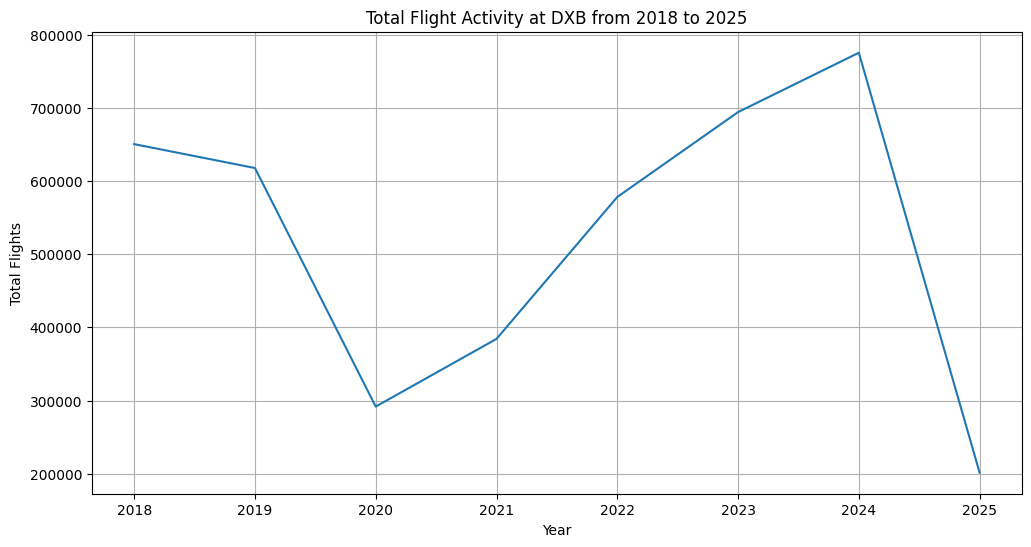

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(flights_yearly["year"], flights_yearly["total_flights"])

plt.xlabel("Year")
plt.ylabel("Total Flights")
plt.title("Total Flight Activity at DXB from 2018 to 2025")

plt.grid(True)

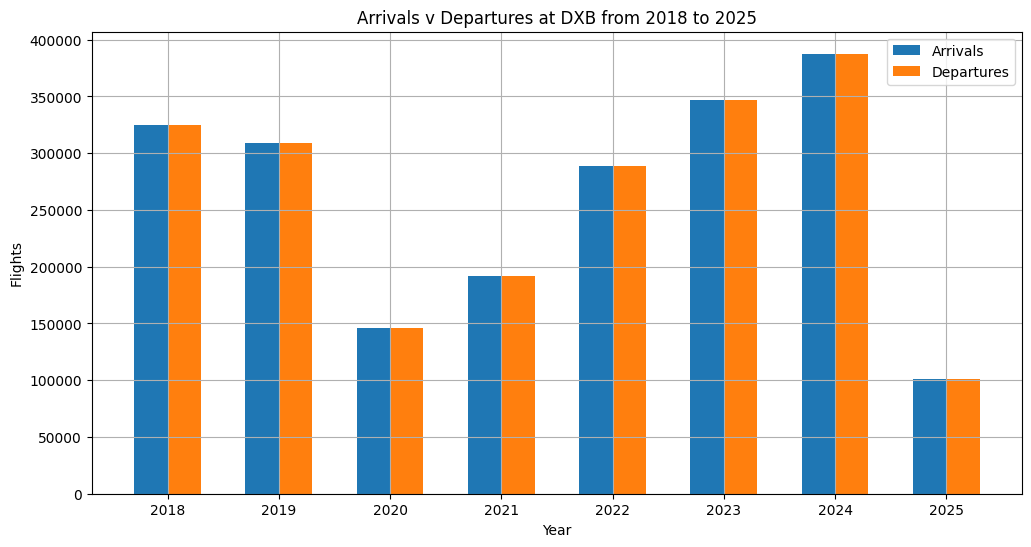

In [ ]:
import numpy as np

x = np.arange(len(flights_yearly["year"]))

plt.figure(figsize=(12,6))

width = 0.3

plt.bar(x - width/2, flights_yearly["arriving_flights"], width, label="Arrivals")
plt.bar(x + width/2, flights_yearly["departing_flights"], width, label="Departures")

plt.xlabel("Year")
plt.ylabel("Flights")
plt.title("Arrivals v Departures at DXB from 2018 to 2025")
plt.xticks(x, flights_yearly["year"])

plt.legend()
plt.grid(True)


<br>

**Inference:**

From the Table and Plot 1 above, we can see that the aviation trend line at DXB has been growing over the past few years.



We also see in Plot 2 that the arrivals and departures numbers are neck and neck with the arrivals having a slight edge on top. We will look more into this in Question 4.

<br>

However, there are 2 evident dips in the graph:

i) 2020 sees a big dip due to COVID-19. We will discuss more about this in Question 3.

ii) The year 2025 also has a very low point, but this is because we only had the data for the first quarter (3 months) of 2025. Hence, the small bar (dip) is expected.

<br>

But apart from this, we can say that DXB has experienced an upward trend or increase in flight volume year on year.

<br>

### **Q2. Seasonal Patterns (Monthly Trends Across All Years)**

The previous question showed us what the annual flight trends are like every year. In this section, we aim to see whether there are any seasonal trends in the data, i.e. whether there is a particular month or period that sees more flight volume in the year compared to the rest.

In [ ]:
flights_monthly = df.groupby("month")[["arriving_flights", "departing_flights", "total_flights"]].sum()

flights_monthly = flights_monthly.reset_index()

flights_monthly

,month,arriving_flights,departing_flights,total_flights
0,April,148011,147988,295999
1,August,168646,168421,337067
2,December,188889,188554,377443
3,February,193932,193986,387918
4,January,214326,214567,428893
5,July,165165,165175,330340
6,June,151622,151827,303449
7,March,203280,203033,406313
8,May,148928,148874,297802
9,November,176906,176930,353836


<br>

From the code and table above, we were able to group total flight counts for each month across all the years.

But there is one evident issue. We can see that the months in the table are in alphabetical order and not in their chronological order. This can be problematic, because if we were to plot the data as it is, interpreting the graph could be difficult and wouldn't really show us seasonal data.

In order to fix this, we now have to map the months correctly using a dictionary and the map function, so that we get them in chronological order. This can be seen below.

<br>

In [ ]:
month_map = {"January":1, "February":2, "March":3, "April":4, "May":5, "June":6, "July":7, "August":8, "September":9, "October":10, "November":11, "December":12}

flights_monthly["month_mapped"] = flights_monthly["month"].map(month_map)
flights_monthly = flights_monthly.sort_values("month_mapped")

flights_monthly

,month,arriving_flights,departing_flights,total_flights,month_mapped
4,January,214326,214567,428893,1
3,February,193932,193986,387918,2
7,March,203280,203033,406313,3
0,April,148011,147988,295999,4
8,May,148928,148874,297802,5
6,June,151622,151827,303449,6
5,July,165165,165175,330340,7
1,August,168646,168421,337067,8
11,September,163480,163305,326785,9
10,October,173836,173378,347214,10


<br>

Now that we have mapped the months correctly, we can go ahead and plot the data.

<br>

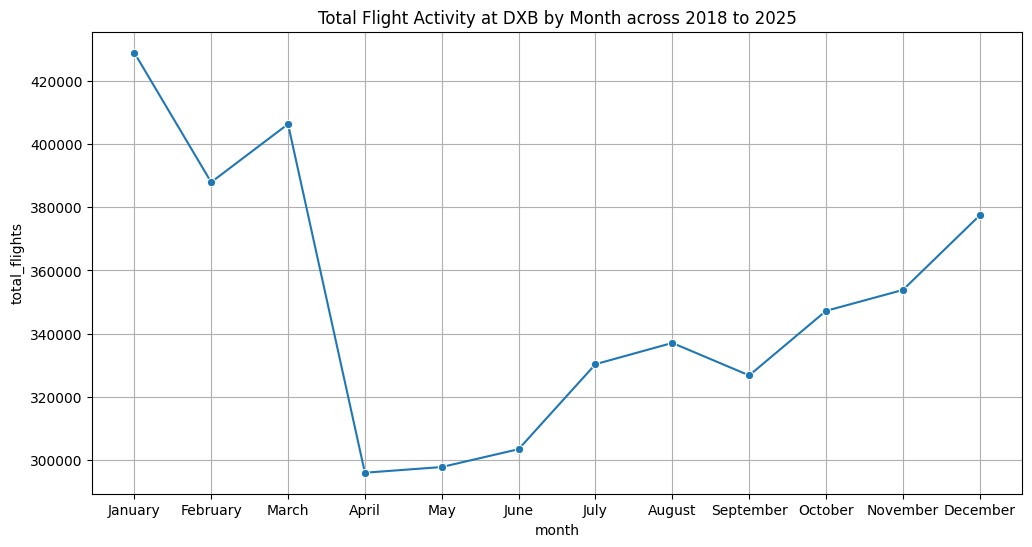

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(data=flights_monthly, x="month", y="total_flights", marker="o")

plt.title("Total Flight Activity at DXB by Month across 2018 to 2025")

plt.grid(True)

<br>

We can also see monthly data on a yearly basis using subplots that show them side by side.

<br>

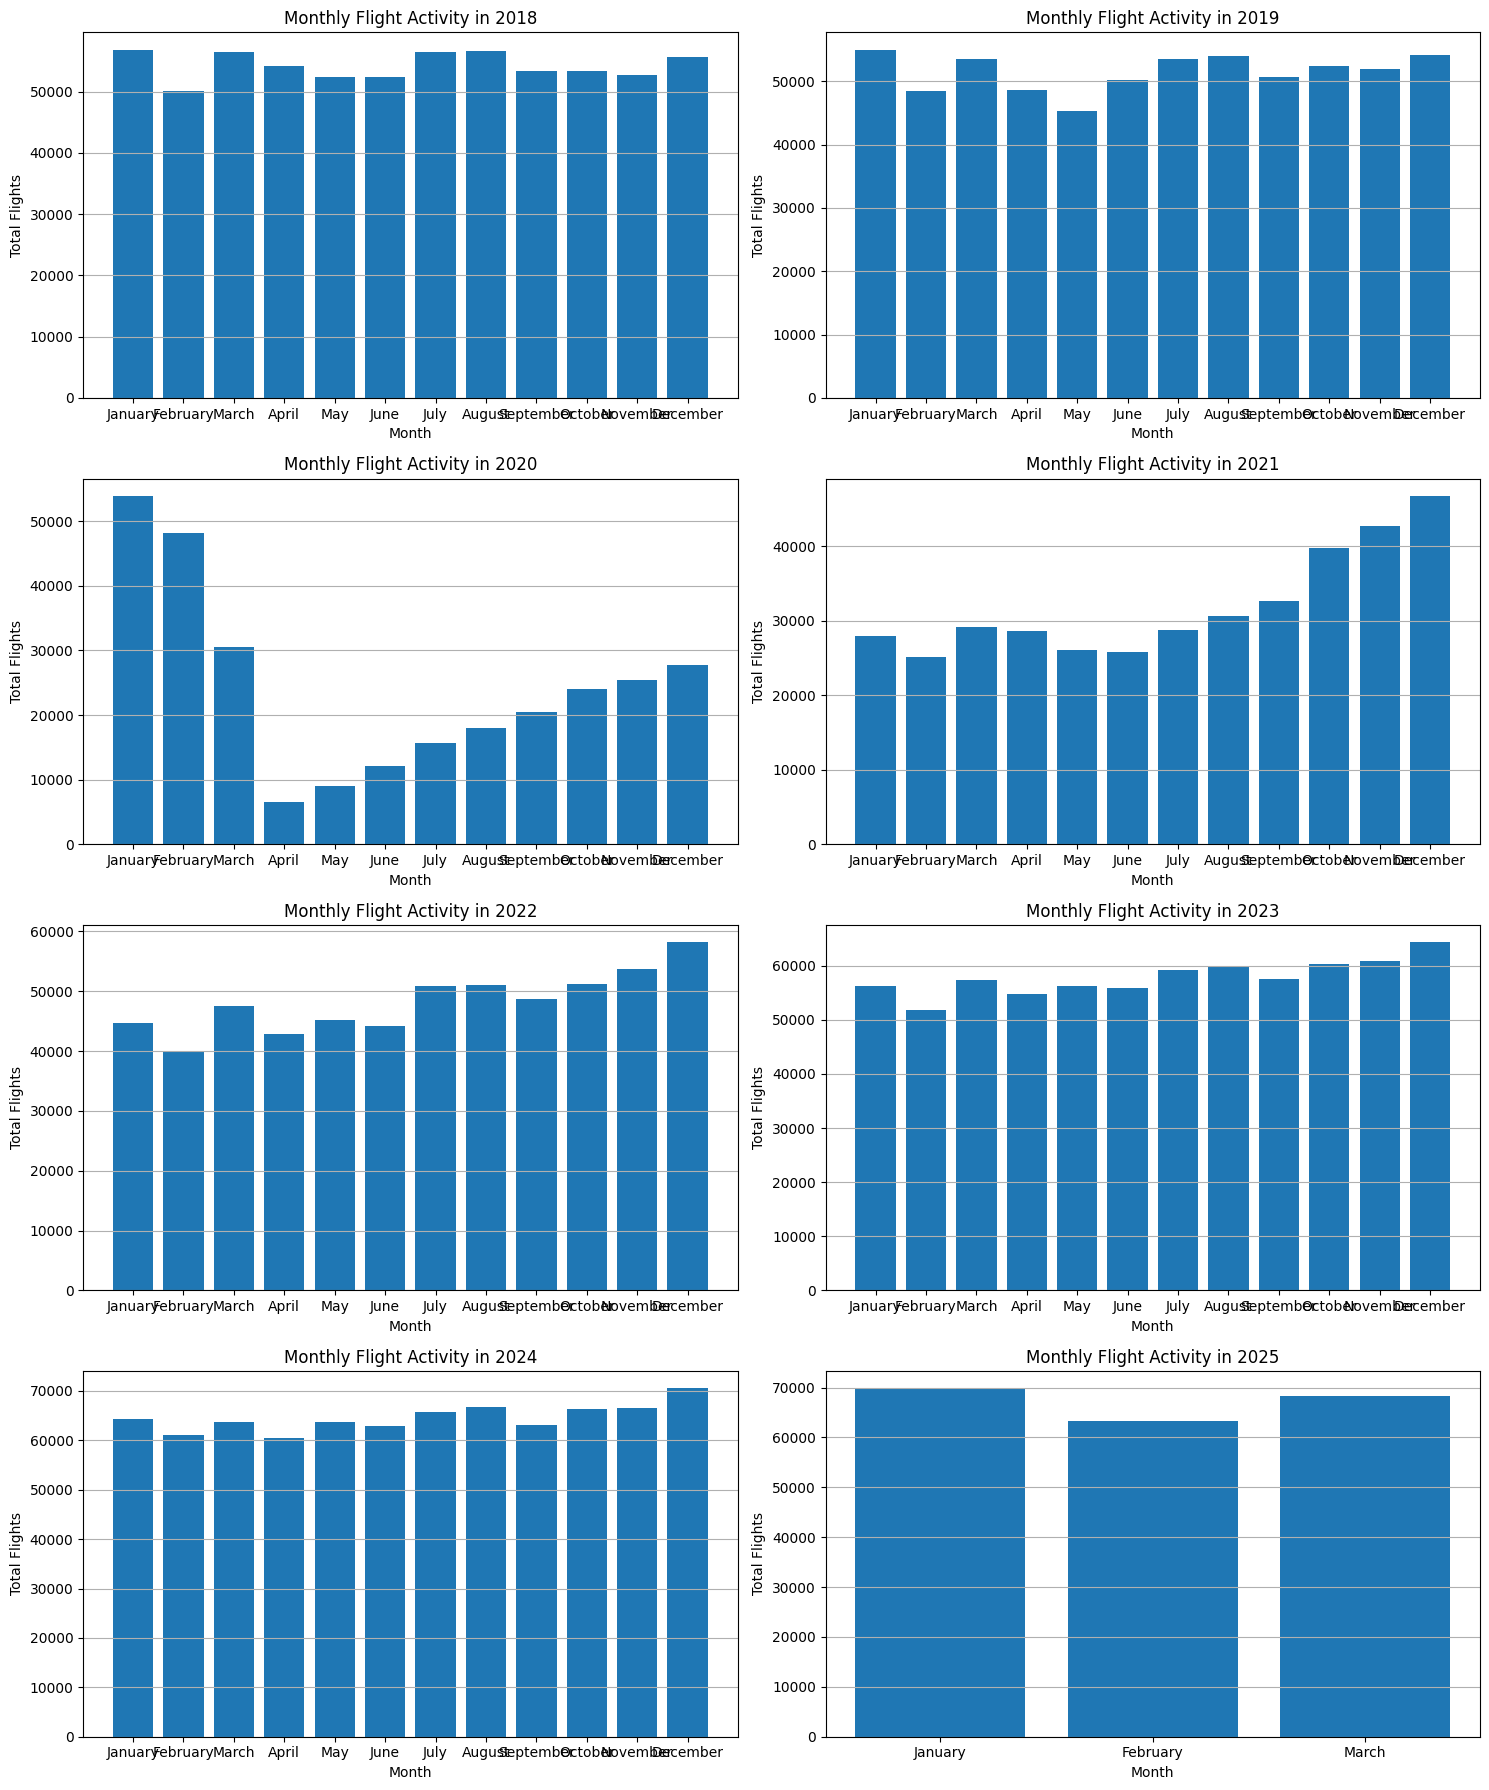

In [ ]:
years = sorted(df["year"].unique())

plt.figure(figsize=(15,18))

for i, yr in enumerate(years, start=1):
  plt.subplot(4, 2, i)
  data_yearly = df[df["year"] == yr]

  plt.bar(data_yearly["month"], data_yearly["total_flights"])
  plt.xlabel("Month")
  plt.ylabel("Total Flights")
  plt.title(f"Monthly Flight Activity in {yr}")

  plt.grid(True, axis='y')
  plt.tight_layout()

<br>

**Inference:**

From the tabular data and the 2 plots above, we can see that DXB operates at a high level with almost a similar volume of flights year round. But if we were to find a seasonal trend, the period between December to March sees the most number of flights at the airport, pointing to the fact that people choose to travel more at this period due to the holiday season and maybe even due to better weather.

<br>

### **Q3. COVID 19 Impact (2018 - 2022)**

In this section, we will be looking into the impact COVID-19 had on flight volume at DXB.

We will only be working within the period of 2018 to 2022, i.e. 2 years to either side of the main lockdown in 2020, as travel restrictions had been eased up on towards the second half of 2022 and we could see how the flight volume trend started to increase again from 2023 onwards in previous grpahs.

<br>

In [ ]:
covid_years = [2018, 2019, 2020, 2021, 2022]

df_covid = df[df["year"].isin(covid_years)]

flights_covid = df_covid.groupby("year")["total_flights"].sum().reset_index()
flights_covid

,year,total_flights
0,2018,650382
1,2019,617714
2,2020,291755
3,2021,384262
4,2022,578156


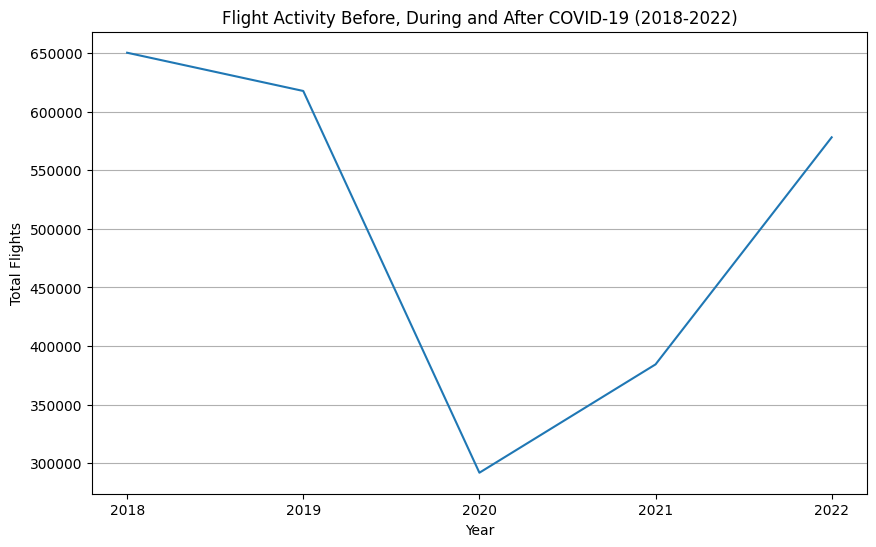

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(flights_covid["year"], flights_covid["total_flights"])

plt.xlabel("Year")
plt.ylabel("Total Flights")
plt.xticks(flights_covid["year"])
plt.title("Flight Activity Before, During and After COVID-19 (2018-2022)")

plt.grid(axis='y')

<br>

We can see from the plot above the huge impact the pandemic had on flight volume in 2020. The airport went from handling over 600 thousand flights a year to less than half of that in 2020 (291,755 flights to be exact).

We will now focus on the year 2020 alone to understand better.

We will first find the monthly flight volume average per year.

<br>

In [ ]:
monthly_avg_pre_covid = df_covid.groupby("year")["total_flights"].mean().reset_index()
monthly_avg_pre_covid

,year,total_flights
0,2018,54198.500000
1,2019,51476.166667
2,2020,24312.916667
3,2021,32021.833333
4,2022,48179.666667


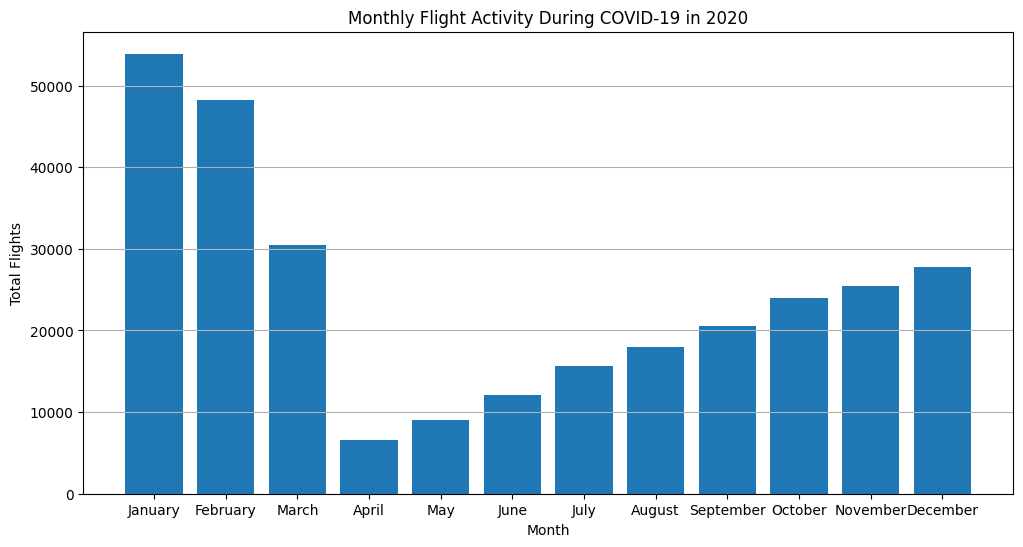

In [ ]:
df_2020 = df[df["year"] == 2020]

plt.figure(figsize=(12,6))

plt.bar(df_2020["month"], df_2020["total_flights"])

plt.xlabel("Month")
plt.ylabel("Total Flights")
plt.title("Monthly Flight Activity During COVID-19 in 2020")

plt.grid(True, axis='y')

<br>

The graph shows accuracy in data as the first lockdown globally was initiated towards the end of March 2020 and early April 2020, and this is seen in the low stump at April 2020 and the months to follow.

<br>

**Inference:**

From the tables and plots above, we can see that the airport that dealt with atleast 50,000 flights a month on average, saw less than a tenth of that in April 2020. Even in the months to follow, the monthly flight count grew but at a very slow rate quite low as compared to the previous years monthly average due to strict travel laws and restrictions.


But operations seemed to pick up again towards 2022 as can be seen from the data and the graphs, and this was expected with the travel restrictions being pulled back on.


From the graphs above and even the ones in Question 1 and 2, we can say that the pandemic had no lasting effect on DXB, as they saw even higher annual flight volumes in the year to follow (2022-2025).

<br>

### **Q4. Correlation Between Arrivals & Departures**

In this section, we will be looking at whether there is any correlation between the arrival and departures count at DXB.

<br>

In [ ]:
df_corr = df[["arriving_flights", "departing_flights"]]
df_corr.corr()

,arriving_flights,departing_flights
arriving_flights,1.000000,0.999973
departing_flights,0.999973,1.000000


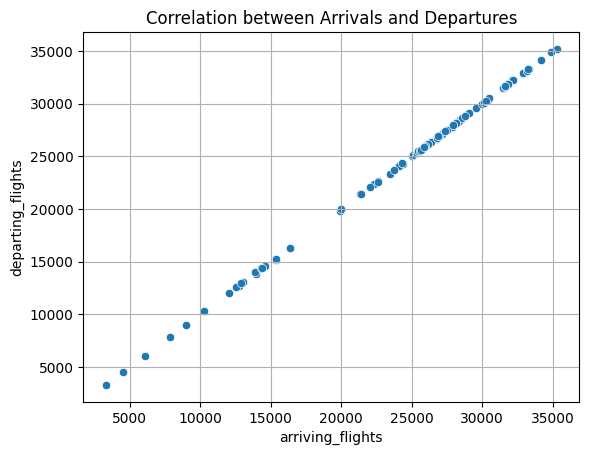

In [ ]:
sns.scatterplot(data=df, x="arriving_flights", y="departing_flights")

plt.title("Correlation between Arrivals and Departures")

plt.grid(True)

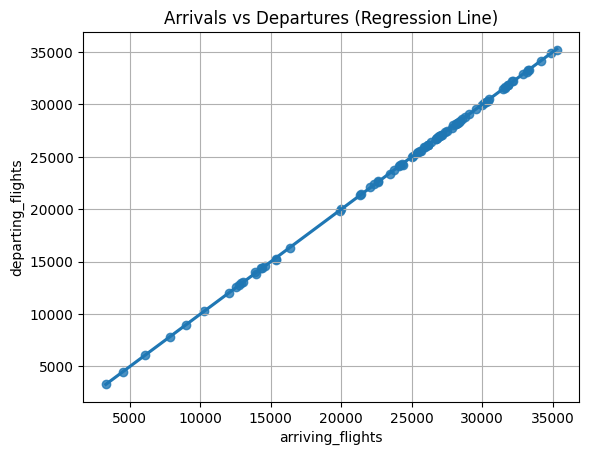

In [ ]:
sns.regplot(x="arriving_flights", y="departing_flights", data=df)

plt.title("Arrivals vs Departures (Regression Line)")

plt.grid(True)

<br>

**Inference:**

From the table and seaborn scatter and regression plots above, we can see that there is a very strong correlation between the arrivals and departures count at DXB.

Now while this correlation is expected, as any flight that arrives will have to depart, the consistent high volumes of both arrivals and departures help us better understand how large and active the airport is.

<br>

### **Q5. Long-Term Trend & Future Projection**

In this section, we will try to better understand Dubai's long term expansion plans by seeing what the future year values would look like.

<br>

In [ ]:
flights_yearly = df.groupby("year")[["total_flights"]].sum().reset_index()

flights_yearly

,year,total_flights
0,2018,650382
1,2019,617714
2,2020,291755
3,2021,384262
4,2022,578156
5,2023,694130
6,2024,775248
7,2025,201412


<br>

A major issue with the above data is that we only have value for the first 3 months fo 2025. So to create a long term trend, we will also need to create an average annual flight count for 2025 to proceed. We look into this below.

<br>

In [ ]:
df_2025 = df[df["year"] == 2025]

avg_2025 = df_2025["total_flights"].mean()
estimated_2025 = avg_2025 * 12

flights_yearly.loc[flights_yearly["year"] == 2025, "total_flights"] = estimated_2025
flights_yearly

,year,total_flights
0,2018,650382
1,2019,617714
2,2020,291755
3,2021,384262
4,2022,578156
5,2023,694130
6,2024,775248
7,2025,805648


<br>

The data shown above for 2025 stands true as we have seen an upward trend from 2023 onwards, so it would make sense to see that trend in 2025 as well, hence the largest annual flight count total so far.

We will now look into calculating the year on year growth at DXB.

<br>

In [ ]:
flights_yearly["yoy_growth"] = (
    flights_yearly["total_flights"].diff() /
    flights_yearly["total_flights"].shift(1)
) * 100

avg_growth = flights_yearly["yoy_growth"].mean()
growth_rate = avg_growth / 100
growth_rate

np.float64(0.08577328065403163)

<br>

For our long term trend and future plan study, we will consider the period from 2026 to 2032 as they plan on fully transitioning into the new airport, Al Maktoum International Airport (DWC) by 2032.

<br>

In [ ]:
projection_years = list(range(2026, 2033))
projection_values = []

last_value = estimated_2025

for year in projection_years:
    next_value = last_value * (1 + growth_rate)
    projection_values.append(next_value)
    last_value = next_value

projection_df = pd.DataFrame({
    "year": projection_years,
    "total_flights": projection_values
})

projection_df

,year,total_flights
0,2026,8.747511e+05
1,2027,9.497813e+05
2,2028,1.031247e+06
3,2029,1.119701e+06
4,2030,1.215741e+06
5,2031,1.320019e+06
6,2032,1.433242e+06


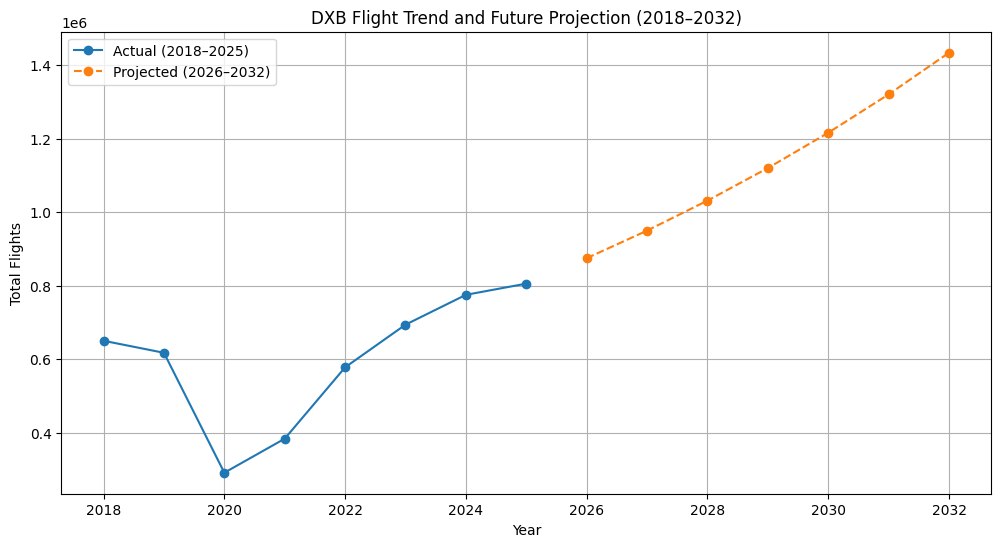

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(flights_yearly["year"], flights_yearly["total_flights"], marker='o', label="Actual (2018–2025)")

plt.plot(projection_df["year"], projection_df["total_flights"], marker='o', linestyle='--', label="Projected (2026–2032)")

plt.xlabel("Year")
plt.ylabel("Total Flights")
plt.title("DXB Flight Trend and Future Projection (2018–2032)")

plt.grid(True)
plt.legend()

<br>

**Inference:**

From the graph above, we are able to see what the flight count trend will be like at DXB for the next 7 years will be (2026-2032).

The growing trend line is a strong support for justifying Dubai's plan to expand operations and move into the new Al Maktoum Internationa Airport (DWC).

<br>

## **Conclusion:**

This analysis of Dubai International Airport's (DXB) flight volumes and movements from 2018 to the first quarter of 2025 has shown a clear long-term growth trajectory. While the airport had a constant average flight volume year round, we were able to spot seasonal peaks towards the winter (December - March), suggesting to us that the airport sees the most number of aricrafts and passengers during this period. We could also see that despite being hit being the COVID-19 pandemic like every other industry, DXB had a strong recovery and bounced back, reaching newer heights in terms of flight volumes. The arrivals and departures were almost perfectly correlated, showing us DXB's balanced and strong flow of aircrafts year round as a major global hub connecting all ends of the world.

We were also able to see from a small projection model the likely increase in flight volume/activity at DXB over the next few years.
As mentioned earlier, despite the dataset being simple and not containing passenger or capacity information, we were still able to see an upward trend in flight volume which supports Dubai's future plan to expand operations at Al Maktoum International Airport (DWC), which would be able to operate at a much higher level.

In conclusion, the dataset and this project has illustrated how DXB recovered from a pandemic, stabilised operations and now continues to grow, falling in line with Dubai's goal of being a major aviation hub.


